In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro
sns.set(style="whitegrid", palette="muted", font_scale=1.05)


In [96]:
data = pd.read_csv("../data/Dataset.txt", sep="	")
data.columns = [
    "Age", "Sex", "Year", "Race", "Cancer_Type",
    "Stage", "Survival_Months", "Vital_Status", "Income"
]
print("Shape del dataset:", data.shape)

Shape del dataset: (50603, 9)


In [97]:
data.head()

,Age,Sex,Year,Race,Cancer_Type,Stage,Survival_Months,Vital_Status,Income
0,15-19 years,Male,2016,White,"C71.9-Brain, NOS",Localized,0091,Alive,"$110,000 - $119,999"
1,15-19 years,Male,2015,White,C71.2-Temporal lobe,Localized,0101,Alive,"$100,000 - $109,999"
2,10-14 years,Female,2013,White,C22.0-Liver,Regional,0122,Alive,"$100,000 - $109,999"
3,10-14 years,Male,2013,White,C73.9-Thyroid gland,Regional,0129,Alive,"$100,000 - $109,999"
4,15-19 years,Female,2021,White,C73.9-Thyroid gland,Blank(s),0031,Alive,"$120,000+"


In [98]:
print("Tipos de datos:", data.dtypes)
print("Resumen estadístico de variables numéricas y categóricas:")
data.describe(include="all").T


Tipos de datos: Age                  str
Sex                  str
Year               int64
Race                 str
Cancer_Type          str
Stage                str
Survival_Months      str
Vital_Status         str
Income               str
dtype: object
Resumen estadístico de variables numéricas y categóricas:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,50603,5,15-19 years,16917,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,50603,2,Male,26967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,50603.0,NaN,NaN,NaN,2017.422564,3.423367,2012.0,2014.0,2017.0,2020.0,2023.0
Race,50603,5,White,38473,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cancer_Type,50603,273,C42.1-Bone marrow,13699,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stage,50603,6,Blank(s),35786,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Survival_Months,50603,145,0000,1352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vital_Status,50603,2,Alive,43775,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,50603,17,"$100,000 - $109,999",5522,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [99]:
data['Age'].unique()

<StringArray>
['15-19 years', '10-14 years', '05-09 years', '00 years', '01-04 years']
Length: 5, dtype: str

In [100]:
data['Year'].unique()

array([2016, 2015, 2013, 2021, 2012, 2020, 2018, 2014, 2019, 2022, 2017,
       2023])

In [101]:
data['Race'].unique()

<StringArray>
[                        'White',     'Asian or Pacific Islander',
                         'Black',                       'Unknown',
 'American Indian/Alaska Native']
Length: 5, dtype: str

In [102]:
data['Cancer_Type'].unique()

<StringArray>
[                                            'C71.9-Brain, NOS',
                                          'C71.2-Temporal lobe',
                                                  'C22.0-Liver',
                                          'C73.9-Thyroid gland',
         'C40.2-Long bones of lower limb and associated joints',
 'C47.1-Periph nerves & autonomic nerv sys: upr limb, shoulder',
                                            'C42.1-Bone marrow',
                                         'C71.5-Ventricle, NOS',
                                           'C71.1-Frontal lobe',
                                           'C75.3-Pineal gland',
 ...
                                        'C76.5-Lower limb, NOS',
                         'C02.2-Ventral surface of tongue, NOS',
                           'C11.0-Superior wall of nasopharynx',
            'C08.8-Overlapping lesion of major salivary glands',
                       'C10.8-Overlapping lesion of oropharynx',
      

In [103]:
data['Survival_Months'].unique()

<StringArray>
['0091', '0101', '0122', '0129', '0031', '0138', '0035', '0027', '0025',
 '0137',
 ...
 '0080', '0086', '0079', '0051', '0077', '0056', '0072', '0071', '0059',
 '0028']
Length: 145, dtype: str

In [104]:
data['Stage'].unique()

<StringArray>
['Localized', 'Regional', 'Blank(s)', 'Distant', 'In situ',
 'Unknown/unstaged']
Length: 6, dtype: str

In [105]:
data['Income'].unique()

<StringArray>
[                   '$110,000 - $119,999',
                    '$100,000 - $109,999',
                              '$120,000+',
                      '$95,000 - $99,999',
                      '$85,000 - $89,999',
                      '$80,000 - $84,999',
                      '$90,000 - $94,999',
                      '$75,000 - $79,999',
                      '$65,000 - $69,999',
                      '$70,000 - $74,999',
 'Unknown/missing/no match/Not 1990-2024',
                      '$60,000 - $64,999',
                      '$55,000 - $59,999',
                      '$50,000 - $54,999',
                      '$45,000 - $49,999',
                              '< $40,000',
                      '$40,000 - $44,999']
Length: 17, dtype: str

In [106]:
# Reemplazar valores no disponibles por NaN
data["Stage"] = data["Stage"].replace(["Blank(s)"],np.nan)
data["Income"] = data["Income"].replace("Unknown/missing/no match/Not 1990-2024",np.nan)
print("Valores faltantes por columna:")
print(data.isnull().sum())
print("\nCantidad de filas duplicadas:")
print(data.duplicated().sum())

Valores faltantes por columna:
Age                    0
Sex                    0
Year                   0
Race                   0
Cancer_Type            0
Stage              35786
Survival_Months        0
Vital_Status           0
Income                 6
dtype: int64

Cantidad de filas duplicadas:
3435


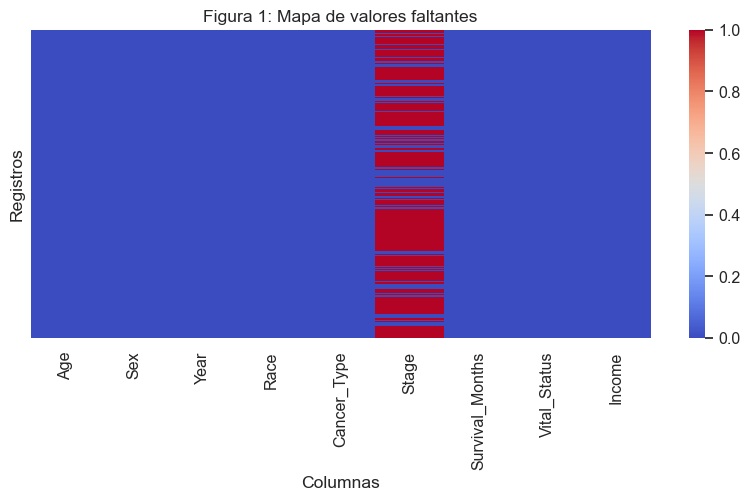

In [107]:
plt.figure(figsize=(10, 4))
sns.heatmap(data.isnull(), cbar=True, cmap="coolwarm", yticklabels=False)
plt.title("Figura 1: Mapa de valores faltantes")
plt.xlabel("Columnas")
plt.ylabel("Registros")
plt.show()


### Descripción de variables clave
- `Age`: rango etario reportado en formato de texto.
- `Sex`: Sexo biológico del paciente
- `Race`: Grupo racial registrado en SEER
- `Vital_Status`: Estado vital de paciente (Alive/Dead)
- `Stage`: Nivel de progresión del cancer (In situ, localized, regional, distant)
- `Cancer_Type`: Tipo de cáncer informado.
- `Survival_Months`: meses de supervivencia.
- `Income`: rango de ingreso.


In [110]:
data["Survival_Months"] = pd.to_numeric(data["Survival_Months"],errors="coerce")

In [111]:
print(data.dtypes)

Age                    str
Sex                    str
Year                 int64
Race                   str
Cancer_Type            str
Stage                  str
Survival_Months    float64
Vital_Status           str
Income                 str
dtype: object


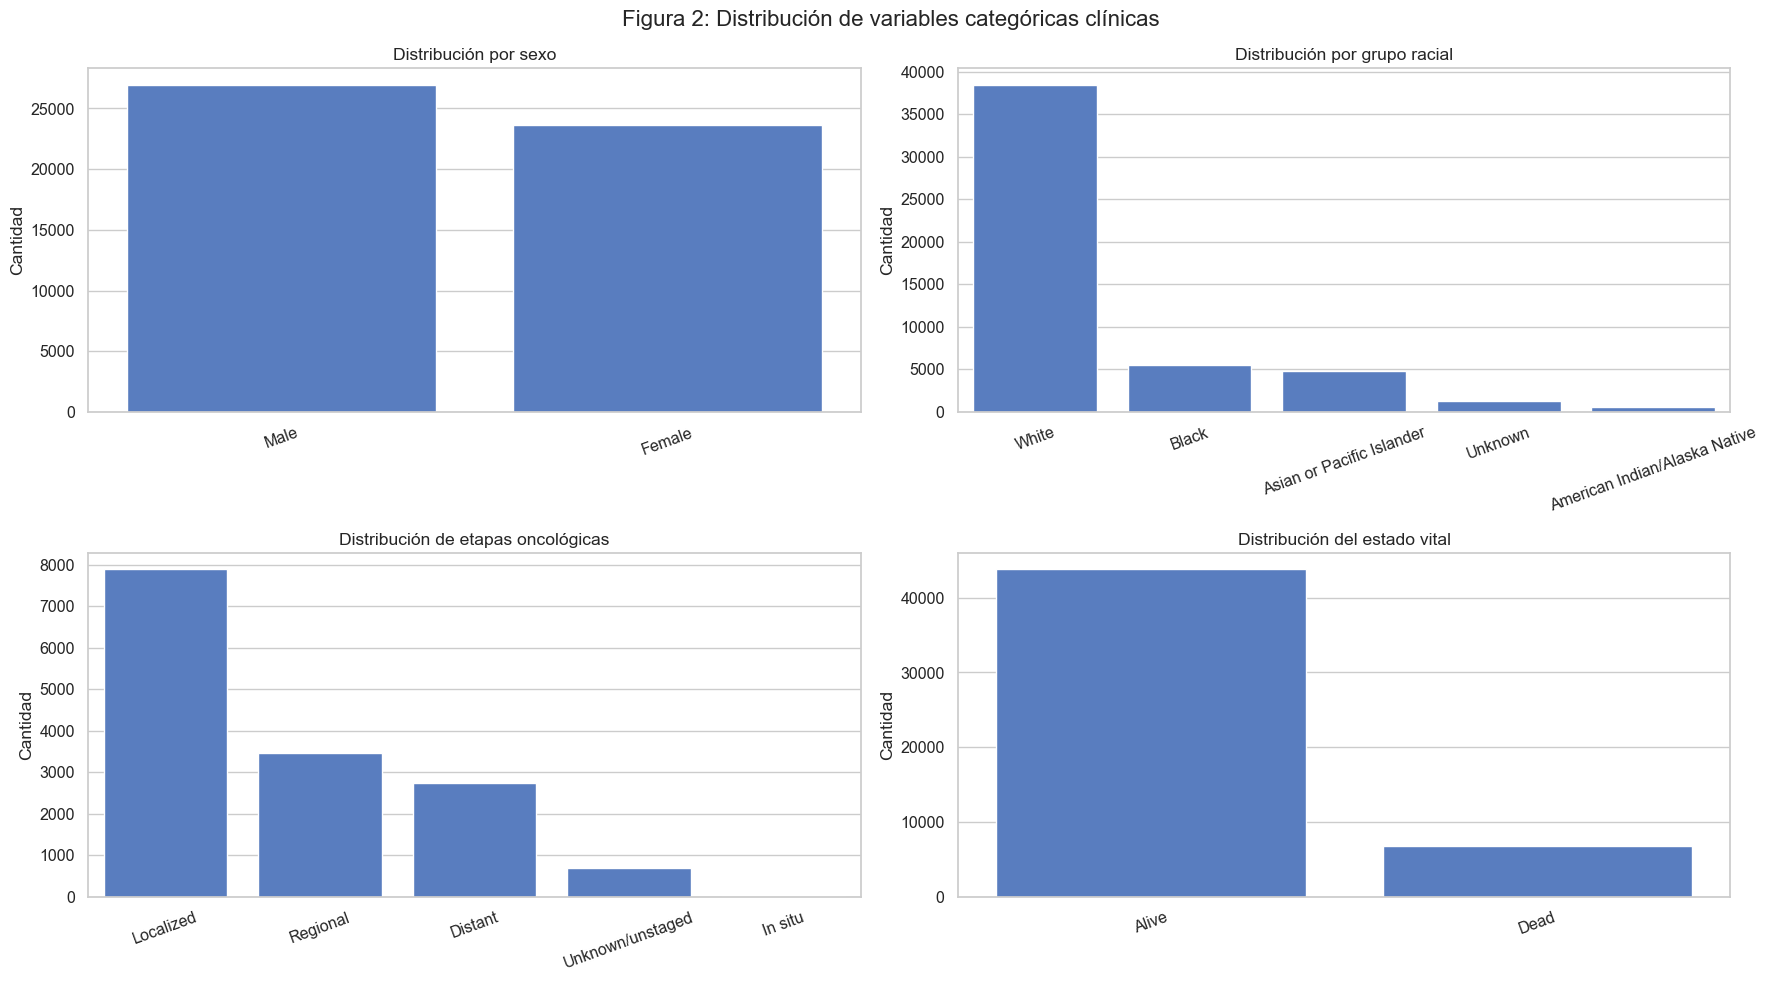

In [119]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
cat_cols = ["Sex", "Race", "Stage", "Vital_Status"]
titulos = [
    "Distribución por sexo",
    "Distribución por grupo racial",
    "Distribución de etapas oncológicas",
    "Distribución del estado vital"
]
for ax, col, titulo in zip(axes.flatten(), cat_cols, titulos):
    sns.countplot( data=data,x=col,order=data[col].value_counts().index,ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel("")
    ax.set_ylabel("Cantidad")
    ax.tick_params(axis='x', rotation=20)
plt.suptitle( "Figura 2: Distribución de variables categóricas clínicas",fontsize=16)
plt.tight_layout()
plt.show()

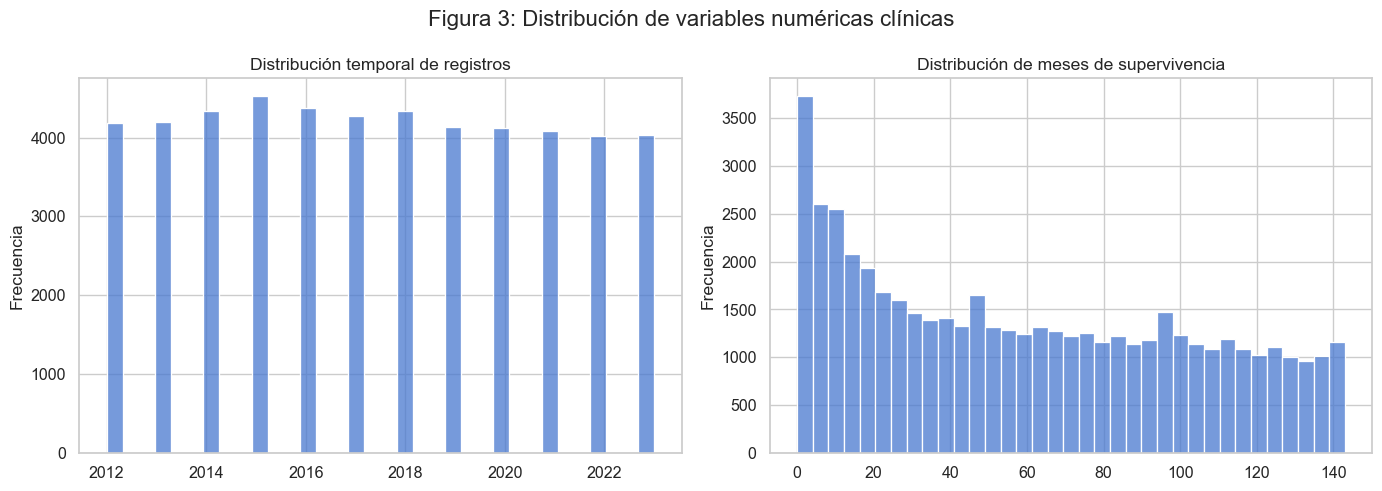

In [123]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

num_cols = ["Year", "Survival_Months"]
titulos = [
    "Distribución temporal de registros",
    "Distribución de meses de supervivencia"
]
for ax, col, titulo in zip(axes.flatten(), num_cols, titulos):
    sns.histplot(data=data,x=col,ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")

plt.suptitle("Figura 3: Distribución de variables numéricas clínicas",fontsize=16)
plt.tight_layout()
plt.show()

In [114]:
print("Top 15 tipos de cáncer:")
data["Cancer_Type"].value_counts().head(15)


Top 15 tipos de cáncer:


Cancer_Type
C42.1-Bone marrow                                       13699
C73.9-Thyroid gland                                      2931
C77.8-Lymph nodes of multiple regions                    2595
C64.9-Kidney, NOS                                        1843
C71.6-Cerebellum, NOS                                    1812
C71.7-Brain stem                                         1540
C40.2-Long bones of lower limb and associated joints     1510
C18.1-Appendix                                           1173
C77.0-Lymph nodes of head, face & neck                   1092
C74.9-Adrenal gland, NOS                                 1077
C56.9-Ovary                                               939
C77.9-Lymph node, NOS                                     937
C71.9-Brain, NOS                                          925
C62.1-Descended testis                                    912
C22.0-Liver                                               837
Name: count, dtype: int64

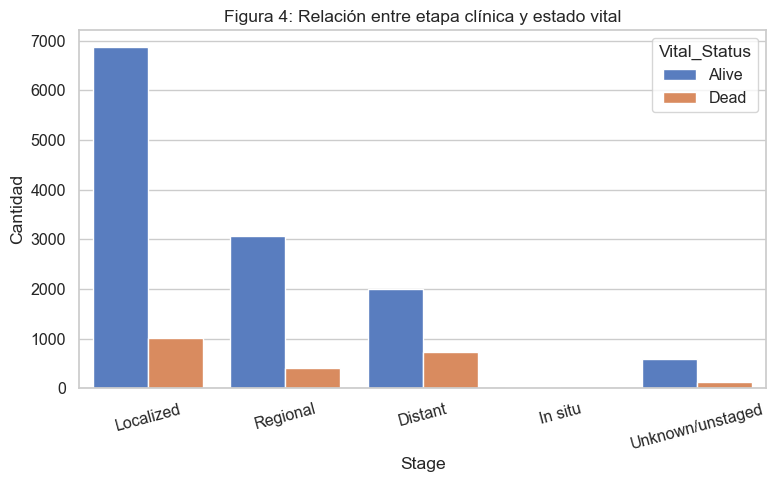

In [117]:
plt.figure(figsize=(8,5))
sns.countplot(data=data,x="Stage",hue="Vital_Status")
plt.title("Figura 4: Relación entre etapa clínica y estado vital")
plt.xlabel("Stage")
plt.ylabel("Cantidad")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

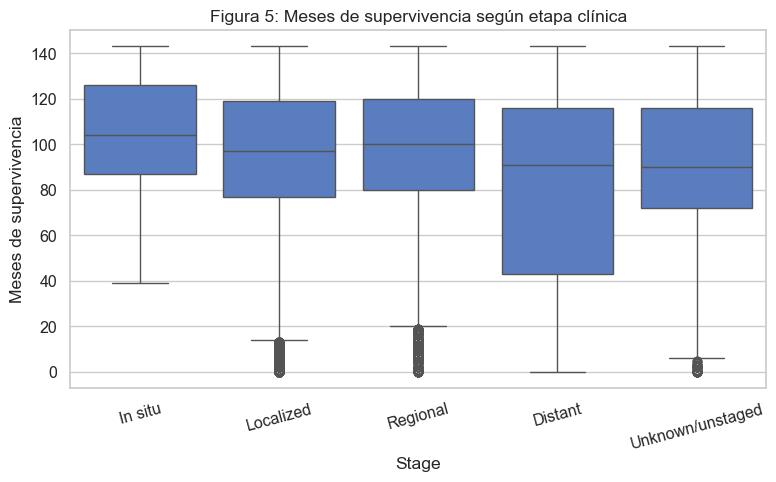

In [124]:
plt.figure(figsize=(8,5))
sns.boxplot(data=data,x="Stage",y="Survival_Months", order=[
    "In situ",
    "Localized",
    "Regional",
    "Distant",
    "Unknown/unstaged"
])
plt.title("Figura 5: Meses de supervivencia según etapa clínica")
plt.xlabel("Stage")
plt.ylabel("Meses de supervivencia")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_30424\874373849.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data_corr.select_dtypes(include="object").columns:


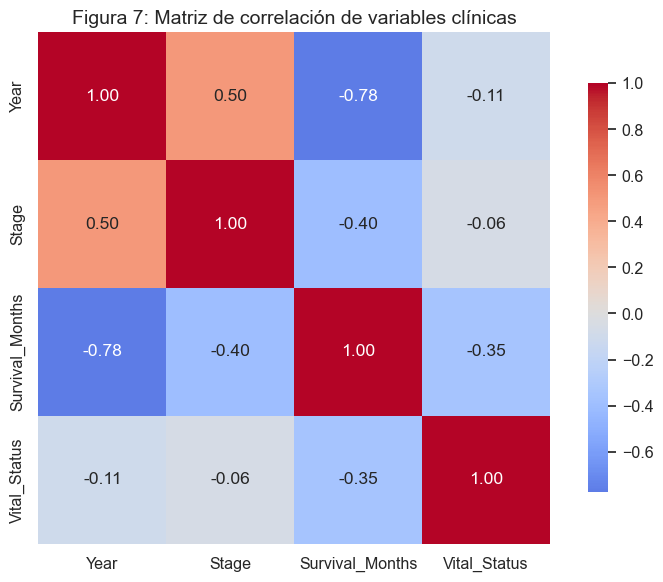

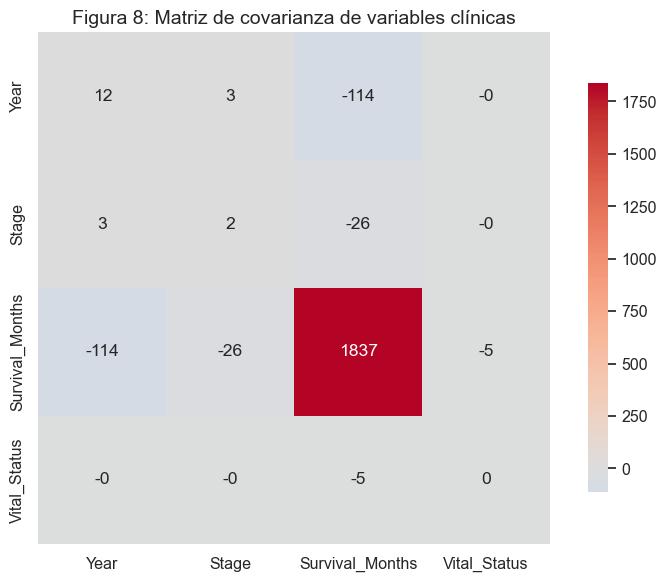

In [126]:
from sklearn.preprocessing import LabelEncoder
data_corr = data.copy()
for col in data_corr.select_dtypes(include="object").columns:
    encoder = LabelEncoder()
    data_corr[col] = encoder.fit_transform(
        data_corr[col].astype(str)
    )

vars_clinicas = ["Year","Stage","Survival_Months","Vital_Status"]
corr = data_corr[vars_clinicas].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",center=0,square=True,cbar_kws={"shrink": .8})
plt.title("Figura 7: Matriz de correlación de variables clínicas",fontsize=14)
plt.tight_layout()
plt.show()
cov = data_corr[vars_clinicas].cov()
plt.figure(figsize=(8,6))
sns.heatmap(cov,annot=True,fmt=".0f",cmap="coolwarm",center=0,square=True,cbar_kws={"shrink": .8})
plt.title("Figura 8: Matriz de covarianza de variables clínicas",fontsize=14)
plt.tight_layout()
plt.show()

In [127]:
from scipy.stats import shapiro

muestra = data["Survival_Months"].dropna()
muestra = muestra.sample(5000, random_state=42)
stat, p = shapiro(muestra)
print("Estadístico:", stat)
print("p-value:", p)

Estadístico: 0.9375153646740033
p-value: 1.2586446145561385e-41


In [134]:
def asignar_prioridad(row):
    # PRIORIDAD ALTA
    if ( row["Stage"] == "Distant" or row["Vital_Status"] == "Dead" or row["Survival_Months"] < 12):
        return "Alta"

    # PRIORIDAD MEDIA
    elif (row["Stage"] == "Regional" or row["Survival_Months"] < 36):
        return "Media"

    # PRIORIDAD BAJA
    else:
        return "Baja"

data["Prioridad"] = data.apply(asignar_prioridad,axis=1)

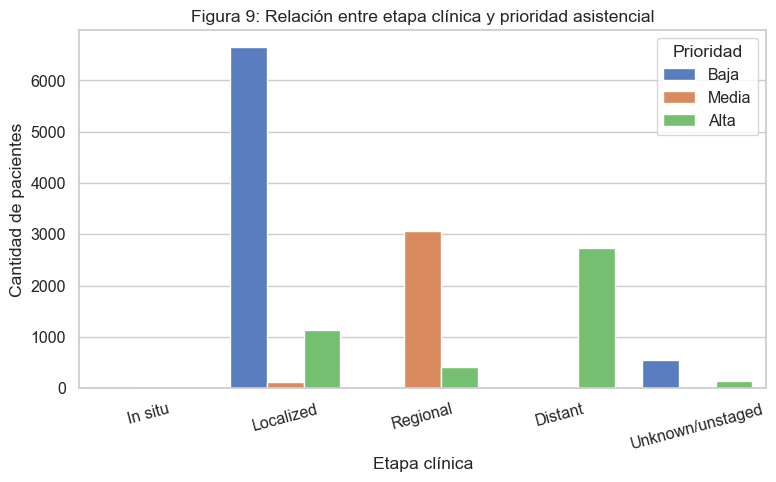

In [133]:
plt.figure(figsize=(8,5))

sns.countplot(data=data,x="Stage",hue="Prioridad",
    order=[
        "In situ",
        "Localized",
        "Regional",
        "Distant",
        "Unknown/unstaged"
    ]
)

plt.title("Figura 9: Relación entre etapa clínica y prioridad asistencial")
plt.xlabel("Etapa clínica")
plt.ylabel("Cantidad de pacientes")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

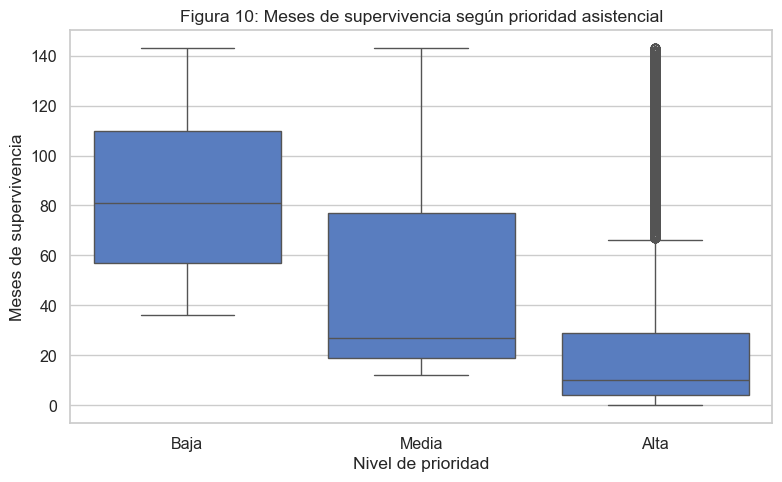

In [132]:
plt.figure(figsize=(8,5))
sns.boxplot(data=data,x="Prioridad",y="Survival_Months")
plt.title("Figura 10: Meses de supervivencia según prioridad asistencial")
plt.xlabel("Nivel de prioridad")
plt.ylabel("Meses de supervivencia")
plt.tight_layout()
plt.show()